# Fourier energy spectrum at a fixed lead time

Log-log plot of the zonal power spectrum for each variable at a chosen time step.
Vertical lines mark the large / medium / small scale band boundaries.

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import sys
sys.path.insert(0, str(Path('..').resolve()))
from utils import SMALL_BANDS, MEDIUM_BANDS, LARGE_BANDS, VARS_LATEX, DEFAULT_VARIABLES

Parameters

In [2]:
model_name  = 'Aurora'

# Time step index to plot (0-based)
it = 318 * 4

COLOR_MODEL = {
    'ERA5':         'black',
    'Aurora':       'tab:cyan',
    'SFNO':         'tab:green',
    'Pangu':        'tab:pink',
    'GraphCast':    'tab:purple',
    'FourCastNet':  'tab:olive',
    'FuXi':         'tab:brown',
    'AIFS':         'tab:red',
    'GenCast':      'tab:orange',
}

Load or compute the energy spectrum

In [ ]:
compute_spectrum = False
if compute_spectrum:
    from spectra.compute_spectra import calculate_energy_spectrum
    pred_path = Path(f'/path/to/pred_{model_name}.nc')
    era5_path = Path('/path/to/ERA5.zarr')

    ds_pred  = xr.open_dataset(pred_path)
    ds_era5 = xr.open_zarr(era5_path, consolidated=False)
    t = ds_pred.time.values[it]

    spectra_pred   = []
    spectra_target = []
    for v in tqdm(DEFAULT_VARIABLES, desc='Spectra'):
        sp = calculate_energy_spectrum(ds_pred[v].sel(time=t).expand_dims('time').compute())
        sp.name = v
        spectra_pred.append(sp)

        parts = v.rsplit('_', 1)
        era5_da = ds_era5[parts[0]].sel(level=int(parts[1])).drop_vars('level') if len(parts) == 2 and parts[1].isdigit() \
                  else ds_era5[v]
        sp_era5 = calculate_energy_spectrum(era5_da.sel(time=t).expand_dims('time').compute())
        sp_era5.name = v
        spectra_target.append(sp_era5)

    spectrum_pred   = xr.merge(spectra_pred)
    spectrum_target = xr.merge(spectra_target)
else:
    spectrum_pred_path = Path(f'/path/to/Fourier_spectrum_{model_name}.nc')
    spectrum_era5_path = Path('/path/to/Fourier_spectrum_target.nc')

    spectrum_pred   = xr.open_dataset(spectrum_pred_path)
    spectrum_target = xr.open_dataset(spectrum_era5_path)

    t = spectrum_pred.time.values[it]

Plotting spectrum at t = 2021-11-15T00


Plot

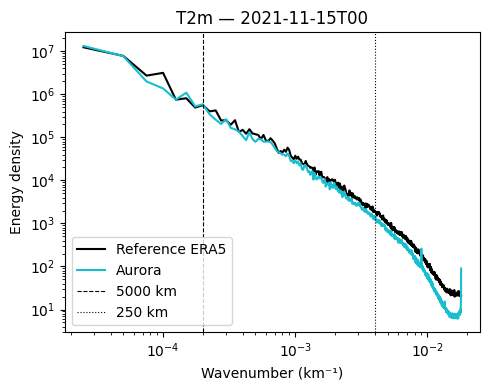

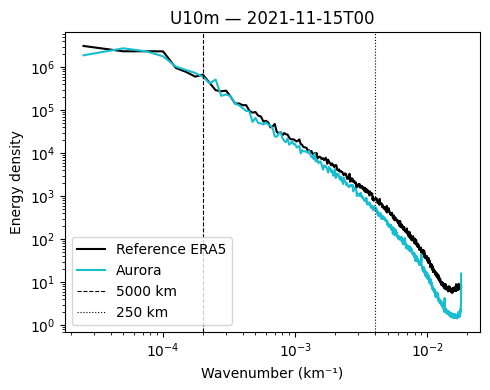

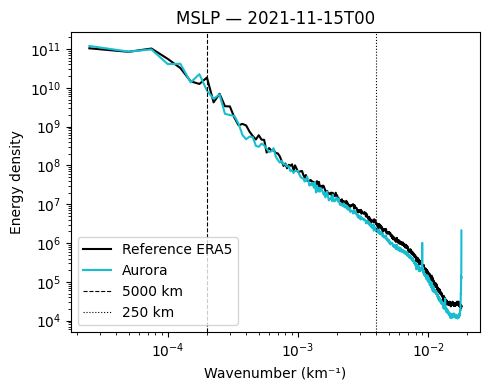

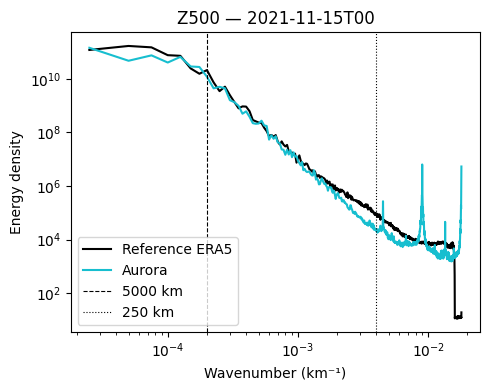

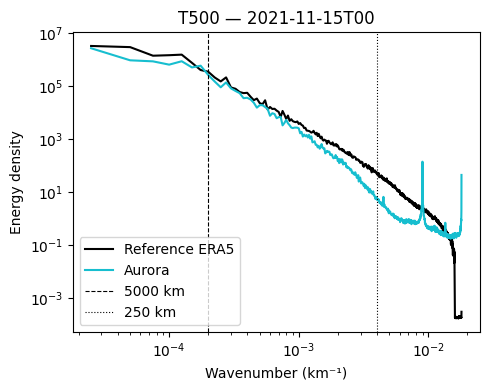

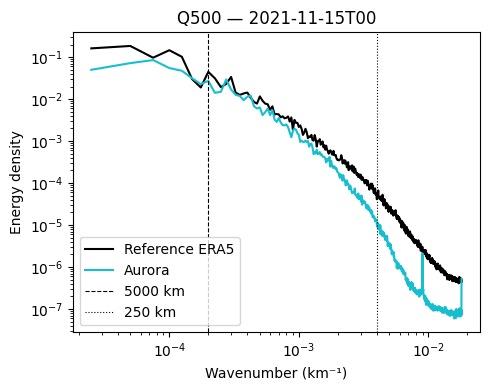

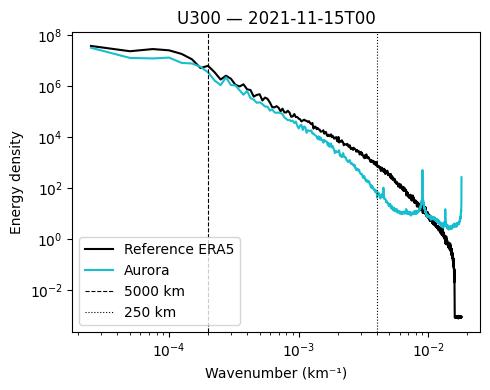

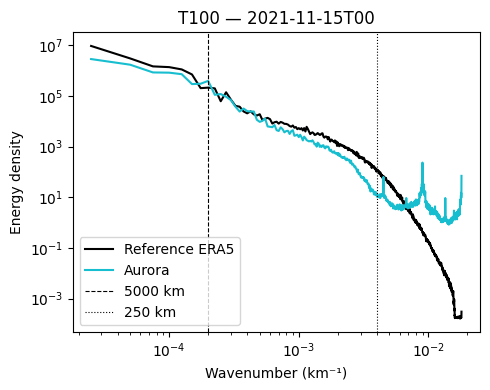

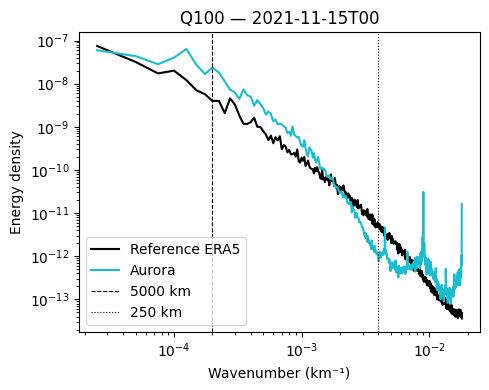

In [ ]:
color = COLOR_MODEL.get(model_name, 'tab:blue')

for var in spectrum_pred.data_vars:
    fig, ax = plt.subplots(figsize=(5, 4))

    ax.loglog(
        spectrum_target.wavenumber,
        spectrum_target.sel(time=t)[var],
        color='k', label='Reference ERA5',
    )
    ax.loglog(
        spectrum_pred.wavenumber,
        spectrum_pred.sel(time=t)[var],
        color=color, label=f'{model_name}',
    )

    ylims = ax.get_ylim()
    ax.set_ylim(ylims)

    # Band boundary lines
    for boundary_km, style in [
        (LARGE_BANDS[0],  dict(lw=0.8, ls='--', color='k', label=f'{LARGE_BANDS[0]} km')),
        (MEDIUM_BANDS[0], dict(lw=0.8, ls=':',  color='k', label=f'{MEDIUM_BANDS[0]} km')),
    ]:
        ax.axvline(1 / boundary_km, **style)

    ax.set_title(f'{VARS_LATEX.get(var, var)} — {it} rollout steps')
    ax.set_xlabel('Wavenumber (km⁻¹)')
    ax.set_ylabel('Energy density')
    ax.legend(loc='lower left')
    fig.tight_layout()
    plt.show()